# 电商用户行为分析项目：EDA、转化漏斗与RFM用户画像


In [1]:
# 导入EDA分析所需依赖
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置图表显示风格，避免中文注释影响代码可读性
plt.style.use("ggplot")


In [2]:
# 读取清洗后的用户行为数据
df = pd.read_csv("../data/clean_user_behavior.csv")

# 将时间字段转为日期时间格式，便于后续分析
if "time" in df.columns:
    df["time"] = pd.to_datetime(df["time"])

df.head()


,user_id,item_id,category_id,behavior_type,timestamp,time,date,hour,weekday
0,237858,1062152,1464116,pv,1512212331,2017-12-02 10:58:51,2017-12-02,10,Saturday
1,44200,3916487,4135836,pv,1511931558,2017-11-29 04:59:18,2017-11-29,4,Wednesday
2,920479,2816757,154040,pv,1512311001,2017-12-03 14:23:21,2017-12-03,14,Sunday
3,239462,2698818,154040,pv,1511783539,2017-11-27 11:52:19,2017-11-27,11,Monday
4,947273,3991295,1029459,pv,1512273837,2017-12-03 04:03:57,2017-12-03,4,Sunday


behavior_type
pv      4479844
cart     275690
fav      143845
buy      100621
Name: count, dtype: int64


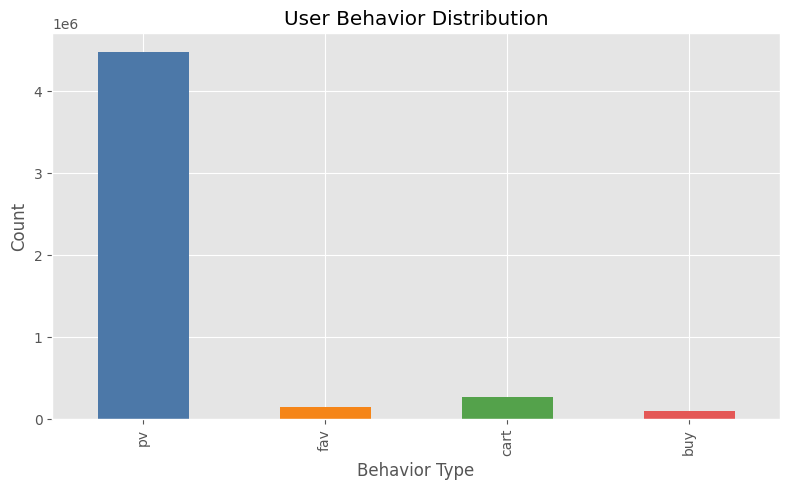

In [3]:
# 统计用户行为类型分布，并绘制柱状图保存到本地
behavior_count = df["behavior_type"].value_counts()
print(behavior_count)

plt.figure(figsize=(8, 5))
behavior_count.reindex(["pv", "fav", "cart", "buy"]).plot(kind="bar", color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
plt.title("User Behavior Distribution")
plt.xlabel("Behavior Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../screenshots/behavior.png", dpi=300)
plt.show()


   hour   count
0     0  170393
1     1  208702
2     2  243612
3     3  237006
4     4  238806


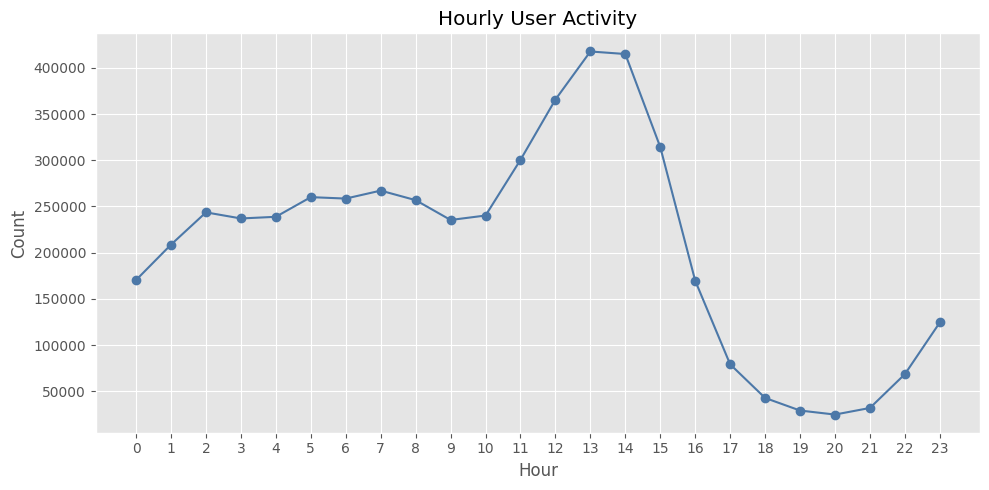

In [4]:
# 按小时统计行为数量，分析用户活跃时间分布
hourly = df.groupby("hour").size().reset_index(name="count")
hourly.to_csv("../data/hourly_activity.csv", index=False)
print(hourly.head())

plt.figure(figsize=(10, 5))
plt.plot(hourly["hour"], hourly["count"], marker="o", color="#4C78A8")
plt.title("Hourly User Activity")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig("../screenshots/hourly.png", dpi=300)
plt.show()


In [5]:
# 统计漏斗各阶段行为量，并保存为Power BI可直接使用的数据文件
pv = len(df[df["behavior_type"] == "pv"])
fav = len(df[df["behavior_type"] == "fav"])
cart = len(df[df["behavior_type"] == "cart"])
buy = len(df[df["behavior_type"] == "buy"])

funnel_df = pd.DataFrame({
    "stage": ["浏览", "收藏", "加购", "购买"],
    "count": [pv, fav, cart, buy]
})
funnel_df.to_csv("../data/funnel_data.csv", index=False)
display(funnel_df)

buy_rate = buy / pv if pv else 0
fav_buy_rate = buy / fav if fav else 0
cart_buy_rate = buy / cart if cart else 0

print(f"浏览到购买整体转化率：{buy_rate:.2%}")
print(f"收藏到购买转化率：{fav_buy_rate:.2%}")
print(f"加购到购买转化率：{cart_buy_rate:.2%}")


,stage,count
0,浏览,4479844
1,收藏,143845
2,加购,275690
3,购买,100621


浏览到购买整体转化率：2.25%
收藏到购买转化率：69.95%
加购到购买转化率：36.50%


user_level
沉睡用户     47534
潜力用户     30575
高价值用户    12468
Name: count, dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_20876\3837225014.py:44: UserWarning: Glyph 27785 (\N{CJK UNIFIED IDEOGRAPH-6C89}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20876\3837225014.py:44: UserWarning: Glyph 30561 (\N{CJK UNIFIED IDEOGRAPH-7761}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20876\3837225014.py:44: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20876\3837225014.py:44: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20876\3837225014.py:44: UserWarning: Glyph 28508 (\N{CJK UNIFIED IDEOGRAPH-6F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_208

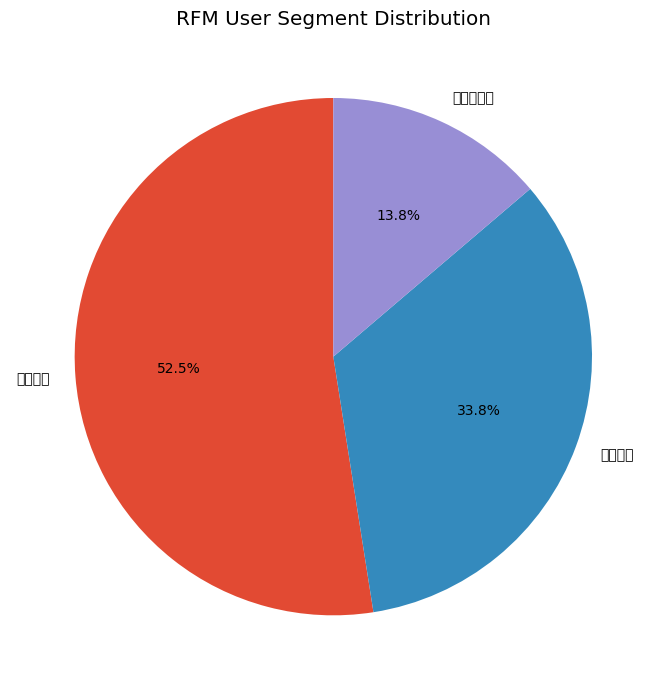

In [6]:
# 基于购买行为构建简化版RFM模型，完成用户价值分层
buy_df = df[df["behavior_type"] == "buy"].copy()
buy_df["time"] = pd.to_datetime(buy_df["time"])
snapshot_date = buy_df["time"].max() + pd.Timedelta(days=1)

rfm = buy_df.groupby("user_id").agg({
    "time": lambda x: (snapshot_date - x.max()).days,
    "behavior_type": "count"
}).reset_index()
rfm.columns = ["user_id", "recency", "frequency"]

# 使用分位数对R和F进行三档打分
r_bins = rfm["recency"].quantile([0, 1/3, 2/3, 1]).values
f_bins = rfm["frequency"].quantile([0, 1/3, 2/3, 1]).values

# 处理分位数重复导致cut报错的情况
r_bins = np.unique(r_bins)
f_bins = np.unique(f_bins)

if len(r_bins) < 4:
    rfm["R_score"] = pd.qcut(rfm["recency"].rank(method="first", ascending=True), 3, labels=[3, 2, 1]).astype(int)
else:
    rfm["R_score"] = pd.cut(rfm["recency"], bins=r_bins, labels=[3, 2, 1], include_lowest=True).astype(int)

if len(f_bins) < 4:
    rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first", ascending=True), 3, labels=[1, 2, 3]).astype(int)
else:
    rfm["F_score"] = pd.cut(rfm["frequency"], bins=f_bins, labels=[1, 2, 3], include_lowest=True).astype(int)

# 按规则划分用户层级
rfm["user_level"] = np.where(
    (rfm["R_score"] == 3) & (rfm["F_score"] == 3),
    "高价值用户",
    np.where((rfm["R_score"] >= 2) & (rfm["F_score"] >= 2), "潜力用户", "沉睡用户")
)

rfm.to_csv("../data/rfm.csv", index=False)
rfm_summary = rfm["user_level"].value_counts()
print(rfm_summary)

plt.figure(figsize=(7, 7))
plt.pie(rfm_summary, labels=rfm_summary.index, autopct="%1.1f%%", startangle=90)
plt.title("RFM User Segment Distribution")
plt.tight_layout()
plt.savefig("../screenshots/rfm.png", dpi=300)
plt.show()


## 项目总结

本项目完成了以下分析：

1. 用户行为分布分析
2. 用户活跃时间分析
3. 浏览-收藏-加购-购买转化漏斗分析
4. RFM用户价值分层
5. Power BI看板数据准备

可写入简历的项目成果：

* 基于淘宝公开用户行为数据集分析500万+行为记录
* 使用Python完成数据清洗、时间字段转换和指标统计
* 构建浏览→收藏→加购→购买转化漏斗模型
* 建立RFM用户价值模型，划分高价值用户、潜力用户和沉睡用户
* 为Power BI运营分析看板准备数据文件
